# Real-asteroid completeness vs SNR / trail length

Mirrors `Evaluation.ipynb::plot_detect_hist` (density mode) using the
LSST `base_PsfFlux` forced photometry SNR — calibrated 1:1 with
`test.csv stack_snr` (Spearman 0.928).


In [1]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

REPO  = Path('/sdf/data/rubin/user/mrakovci/Projects/Asteroid_detection_CNN')
RES   = REPO / 'experiments' / 'diffim_runs' / 'test_real' / 'results'
FCSV  = Path('/sdf/scratch/users/m/mrakovci/realneg/per_sighting_forced_lsst.csv')

fp = pd.read_csv(FCSV)
fp = fp[~fp.failed].copy()
ps = pd.read_csv(RES / 'per_sighting.csv')

# Per-sighting catalog with: lsst_psf_snr, trail_length, stack_detected, nn_detected
cat = fp.merge(ps[['ObjID','visit','detector','nn_detected','stack_detected']],
               on=['ObjID','visit','detector'], how='left',
               suffixes=('','_dup'))
# Use the geometry/state from the forced CSV (already joined); drop dup columns
cat = cat.drop(columns=[c for c in cat.columns if c.endswith('_dup')])
print(f'sightings: {len(cat)}')
print(f'  stack: {int(cat.stack_detected.sum())}   '
      f'NN: {int(cat.nn_detected.sum())}   '
      f'combined: {int((cat.stack_detected | cat.nn_detected).sum())}')

sightings: 2230
  stack: 1313   NN: 262   combined: 1359


In [2]:
def plot_completeness(cat, field, bins=12, xlim=None, title=None, log_x=False):
    """Same density-mode logic as Evaluation.ipynb plot_detect_hist:
    for each bin, plot detected/all. Three curves: stack, NN, combined."""
    v = cat[field].to_numpy().astype(float)
    v = v[np.isfinite(v)]
    if xlim is not None:
        v = v[(v >= xlim[0]) & (v <= xlim[1])]
    edges = np.histogram_bin_edges(v, bins=bins)
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    all_i = np.histogram(cat[field], bins=edges)[0].astype(float)
    for label, mask, color in [
        ('stack 5σ',     cat.stack_detected,                      '#4c72b0'),
        ('NN (thr 0.5)', cat.nn_detected,                          '#dd8452'),
        ('combined',     cat.stack_detected | cat.nn_detected,    '#55a868'),
    ]:
        det_i = np.histogram(cat[cat[field].notna() & mask][field], bins=edges)[0].astype(float)
        ax.stairs(det_i / np.maximum(all_i, 1), edges, label=label, color=color, lw=2)
    ax.set_xlabel(field.replace('_', ' '))
    ax.set_ylabel('Completeness')
    if log_x:
        ax.set_xscale('symlog', linthresh=3)
    if title:
        ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)
    ax.legend(loc='best')
    plt.tight_layout()
    return fig, ax

## SNR histogram (LSST forced PSF SNR)

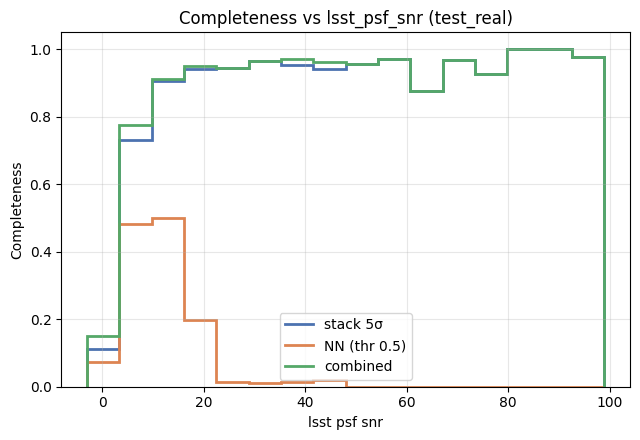

In [3]:
plot_completeness(cat, 'lsst_psf_snr', bins=16, xlim=(-3, 100),
                  title='Completeness vs lsst_psf_snr (test_real)')
plt.show()

## Trail length histogram

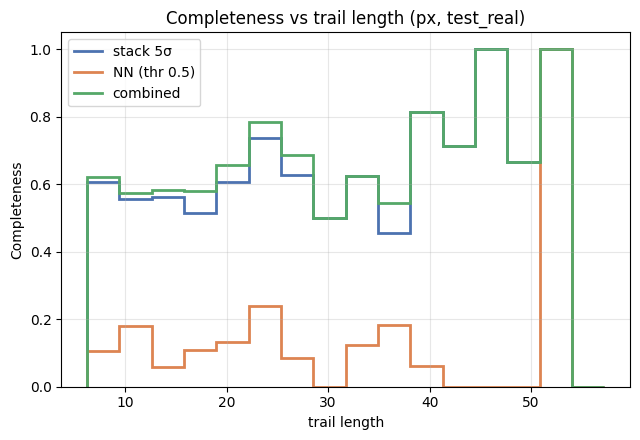

In [4]:
plot_completeness(cat, 'trail_length', bins=16, xlim=(0, 60),
                  title='Completeness vs trail length (px, test_real)')
plt.show()